In [5]:
import kagglehub
import os
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from PIL import Image, ImageTk
from random import sample
import seaborn as sns
import tkinter as tk
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, AveragePooling2D, GlobalAveragePooling2D, GlobalMaxPooling2D
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Загрузка данных

In [6]:
os.environ["KAGGLEHUB_CACHE"] = "data/kagglehub_cache"

path = kagglehub.dataset_download(
    "balabaskar/tom-and-jerry-image-classification"
)

print("Dataset path:", path)

Dataset path: data/kagglehub_cache\datasets\balabaskar\tom-and-jerry-image-classification\versions\3


# Подготовка выборок

In [7]:
def load_images_from_folders(tom_path, jerry_path):
    images = []
    labels = []

    for file in os.listdir(jerry_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(jerry_path, file)
            image = Image.open(img_path).convert('RGB')
            image = image.resize((128, 128))
            image_array = np.array(image) / 255.0
            images.append(image_array)
            labels.append(0)

    for file in os.listdir(tom_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(tom_path, file)
            image = Image.open(img_path).convert('RGB')
            image = image.resize((128, 128))
            image_array = np.array(image) / 255.0
            images.append(image_array)
            labels.append(1)

    return np.array(images), np.array(labels)


tom_path = r"data\kagglehub_cache\datasets\balabaskar\tom-and-jerry-image-classification\versions\3\tom_and_jerry\tom_and_jerry\tom"
jerry_path = r"data\kagglehub_cache\datasets\balabaskar\tom-and-jerry-image-classification\versions\3\tom_and_jerry\tom_and_jerry\jerry"

X, Y = load_images_from_folders(tom_path, jerry_path)

sss = StratifiedShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(sss.split(X, Y))

x_train, x_test = X[train_idx], X[test_idx]
y_train, y_test = Y[train_idx].astype(np.float32), Y[test_idx].astype(np.float32)

In [8]:
print(x_train.shape)
print(x_test.shape)

(2536, 128, 128, 3)
(634, 128, 128, 3)


# Проверка сбалансированности классов

In [9]:
def check_class_balance(labels, name):
    unique, counts = np.unique(labels, return_counts=True)

    print(f"\n{name} distribution:")
    for u, c in zip(unique, counts):
        class_name = "Jerry (0)" if u == 0 else "Tom (1)"
        percent = (c / len(labels)) * 100
        print(f"{class_name}: {c} images ({percent:.2f}%)")

check_class_balance(y_train, "Train set")
check_class_balance(y_test, "Test set")


Train set distribution:
Jerry (0): 992 images (39.12%)
Tom (1): 1544 images (60.88%)

Test set distribution:
Jerry (0): 248 images (39.12%)
Tom (1): 386 images (60.88%)


# Max poolling

In [10]:
# описание модели
model_max = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [11]:
# сборка модели
model_max.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# обучение модели
model_max.fit(x_train, y_train, batch_size=16,
          epochs=5,
          validation_data=(x_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 22s 134ms/step - accuracy: 0.6585 - loss: 0.6110 - val_accuracy: 0.8454 - val_loss: 0.4069
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.8281 - loss: 0.3999 - val_accuracy: 0.9211 - val_loss: 0.2477
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9002 - loss: 0.2477 - val_accuracy: 0.8959 - val_loss: 0.2937
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9306 - loss: 0.2016 - val_accuracy: 0.9401 - val_loss: 0.1715
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9452 - loss: 0.1486 - val_accuracy: 0.9274 - val_loss: 0.1818


In [12]:
# проверка модели на тестовых данных
predictions_max = model_max.predict(x_test)
binary_predictions_max = (predictions_max > 0.5).astype(int).flatten()
accuracy_max = np.mean(y_test == binary_predictions_max)
print(f'Точность предсказания на тестовых данных : {accuracy_max * 100:.5f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Точность предсказания на тестовых данных : 92.74448%



Метрики классификации:
              precision    recall  f1-score   support

       Джери       0.86      0.97      0.91       248
         Том       0.98      0.90      0.94       386

    accuracy                           0.93       634
   macro avg       0.92      0.94      0.93       634
weighted avg       0.93      0.93      0.93       634



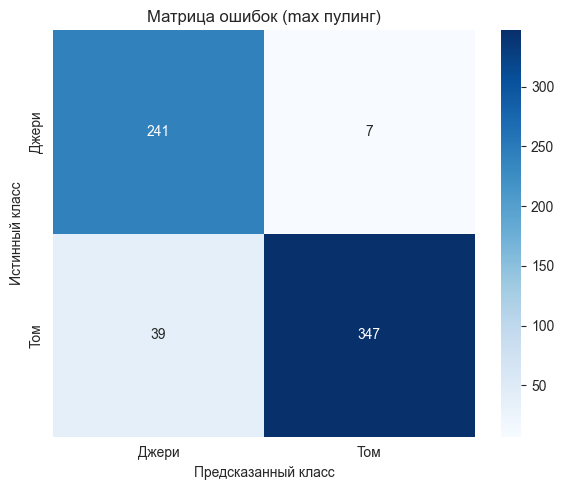

In [13]:
cm_max = confusion_matrix(y_test, binary_predictions_max)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_max,
    target_names=['Джери', 'Том']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_max,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Джери", "Том"],
    yticklabels=["Джери", "Том"],
    cbar=True
)

plt.title("Матрица ошибок (max пулинг)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# Average Pooling

In [14]:
# описание модели
model_avg = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    AveragePooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    AveragePooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    AveragePooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [15]:
# сборка модели
model_avg.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# обучение модели
model_avg.fit(x_train, y_train, batch_size=16,
              epochs=5,
              validation_data=(x_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.6266 - loss: 0.6530 - val_accuracy: 0.6893 - val_loss: 0.5859
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.6995 - loss: 0.5778 - val_accuracy: 0.7224 - val_loss: 0.5608
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.7520 - loss: 0.5069 - val_accuracy: 0.7997 - val_loss: 0.4374
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.8222 - loss: 0.4134 - val_accuracy: 0.8517 - val_loss: 0.3576
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 28s 176ms/step - accuracy: 0.8632 - loss: 0.3479 - val_accuracy: 0.8991 - val_loss: 0.2946


In [16]:
# проверка модели на тестовых данных
predictions_avg = model_avg.predict(x_test)
binary_predictions_avg = (predictions_avg > 0.5).astype(int).flatten()
accuracy_avg = np.mean(y_test == binary_predictions_max)
print(f'Точность предсказания на тестовых данных : {accuracy_avg * 100:.5f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
Точность предсказания на тестовых данных : 92.74448%



Метрики классификации:
              precision    recall  f1-score   support

       Джери       0.90      0.84      0.87       248
         Том       0.90      0.94      0.92       386

    accuracy                           0.90       634
   macro avg       0.90      0.89      0.89       634
weighted avg       0.90      0.90      0.90       634



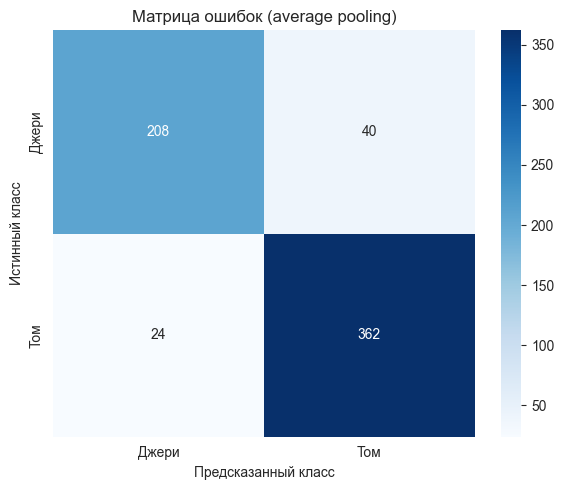

In [32]:
cm_avg = confusion_matrix(y_test, binary_predictions_avg)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_avg,
    target_names=['Джери', 'Том']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_avg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Джери", "Том"],
    yticklabels=["Джери", "Том"],
    cbar=True
)

plt.title("Матрица ошибок (average pooling)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# Global Average Pooling

In [18]:
# описание модели
model_global_avg = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [19]:
# сборка модели
model_global_avg.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# обучение модели
model_global_avg.fit(x_train, y_train, batch_size=16,
              epochs=5,
              validation_data=(x_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - accuracy: 0.6100 - loss: 0.6619 - val_accuracy: 0.6088 - val_loss: 0.6504
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.6293 - loss: 0.6373 - val_accuracy: 0.6956 - val_loss: 0.5863
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 30s 167ms/step - accuracy: 0.7330 - loss: 0.5467 - val_accuracy: 0.7555 - val_loss: 0.5357
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 27s 171ms/step - accuracy: 0.8127 - loss: 0.4356 - val_accuracy: 0.8486 - val_loss: 0.3580
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 40s 166ms/step - accuracy: 0.8667 - loss: 0.3379 - val_accuracy: 0.8596 - val_loss: 0.3150


In [20]:
# проверка модели на тестовых данных
predictions_global_avg = model_global_avg.predict(x_test)
binary_predictions_global_avg = (predictions_global_avg > 0.5).astype(int).flatten()
accuracy_global_avg = np.mean(y_test == binary_predictions_global_avg)
print(f'Точность предсказания на тестовых данных : {accuracy_global_avg * 100:.5f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step
Точность предсказания на тестовых данных : 85.96215%



Метрики классификации:
              precision    recall  f1-score   support

       Джери       0.76      0.94      0.84       248
         Том       0.95      0.81      0.88       386

    accuracy                           0.86       634
   macro avg       0.86      0.87      0.86       634
weighted avg       0.88      0.86      0.86       634



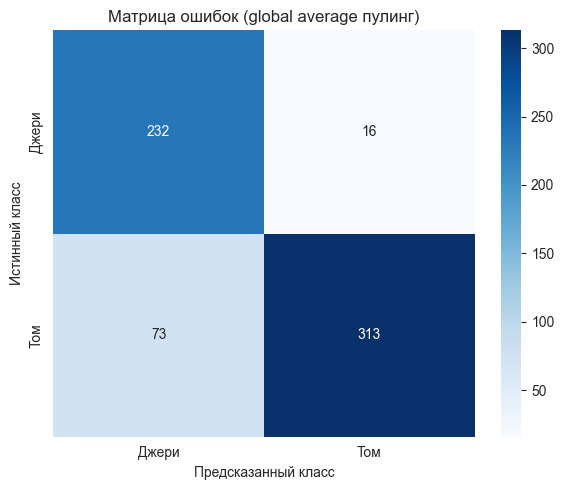

In [21]:
cm_global_avg = confusion_matrix(y_test, binary_predictions_global_avg)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_global_avg,
    target_names=['Джери', 'Том']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_global_avg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Джери", "Том"],
    yticklabels=["Джери", "Том"],
    cbar=True
)

plt.title("Матрица ошибок (global average пулинг)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# Global Max Pooling

In [22]:
# описание модели
model_global_max = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    GlobalMaxPooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [23]:
# сборка модели
model_global_max.compile(optimizer='adam',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

# обучение модели
model_global_max.fit(x_train, y_train, batch_size=16,
                     epochs=5,
                     validation_data=(x_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 29s 168ms/step - accuracy: 0.6739 - loss: 0.5859 - val_accuracy: 0.8707 - val_loss: 0.3593
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 41s 170ms/step - accuracy: 0.8533 - loss: 0.3511 - val_accuracy: 0.7776 - val_loss: 0.4558
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - accuracy: 0.9132 - loss: 0.2387 - val_accuracy: 0.9385 - val_loss: 0.1756
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9416 - loss: 0.1729 - val_accuracy: 0.9590 - val_loss: 0.1202
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.9610 - loss: 0.1187 - val_accuracy: 0.9558 - val_loss: 0.1175


In [24]:
# проверка модели на тестовых данных
predictions_global_max = model_global_max.predict(x_test)
binary_predictions_global_max = (predictions_global_max > 0.5).astype(int).flatten()
accuracy_global_max = np.mean(y_test == binary_predictions_global_max)
print(f'Точность предсказания на тестовых данных : {accuracy_global_max * 100:.5f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Точность предсказания на тестовых данных : 95.58360%



Метрики классификации:
              precision    recall  f1-score   support

       Джери       0.91      0.98      0.95       248
         Том       0.99      0.94      0.96       386

    accuracy                           0.96       634
   macro avg       0.95      0.96      0.95       634
weighted avg       0.96      0.96      0.96       634



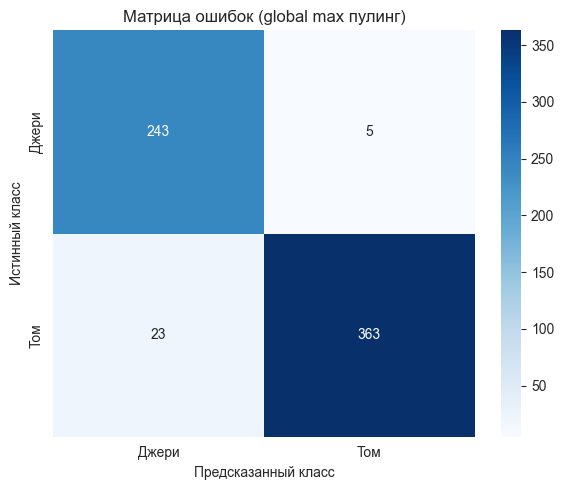

In [25]:
cm_global_max = confusion_matrix(y_test, binary_predictions_global_max)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_global_max,
    target_names=['Джери', 'Том']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_global_max,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Джери", "Том"],
    yticklabels=["Джери", "Том"],
    cbar=True
)

plt.title("Матрица ошибок (global max пулинг)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# Mixed Pooling

In [26]:
# описание модели
model_mixed = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    AveragePooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [27]:
# сборка модели
model_mixed.compile(optimizer='adam',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

# обучение модели
model_mixed.fit(x_train, y_train, batch_size=16,
                     epochs=5,
                     validation_data=(x_test, y_test))

Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.6329 - loss: 0.6405 - val_accuracy: 0.7729 - val_loss: 0.5089
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - accuracy: 0.7658 - loss: 0.4969 - val_accuracy: 0.8770 - val_loss: 0.3113
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8683 - loss: 0.3288 - val_accuracy: 0.9180 - val_loss: 0.2485
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.9129 - loss: 0.2424 - val_accuracy: 0.9038 - val_loss: 0.2452
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9357 - loss: 0.1735 - val_accuracy: 0.9290 - val_loss: 0.2181


In [28]:
# проверка модели на тестовых данных
predictions_mixed = model_mixed.predict(x_test)
binary_predictions_mixed = (predictions_mixed > 0.5).astype(int).flatten()
accuracy_mixed = np.mean(y_test == binary_predictions_mixed)
print(f'Точность предсказания на тестовых данных : {accuracy_mixed * 100:.5f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Точность предсказания на тестовых данных : 92.90221%



Метрики классификации:
              precision    recall  f1-score   support

       Джери       0.95      0.86      0.90       248
         Том       0.92      0.97      0.94       386

    accuracy                           0.93       634
   macro avg       0.93      0.92      0.92       634
weighted avg       0.93      0.93      0.93       634



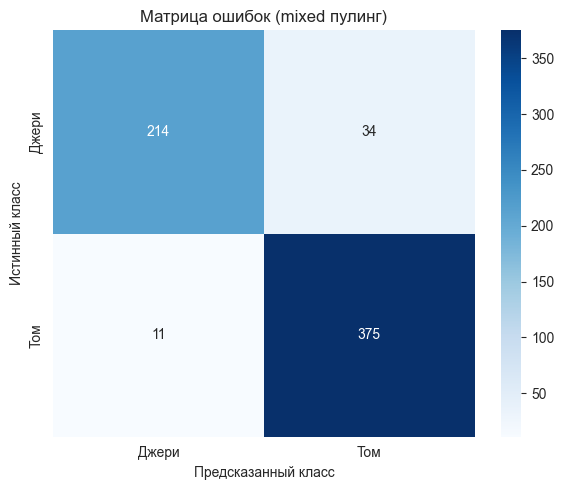

In [29]:
cm_mixed = confusion_matrix(y_test, binary_predictions_mixed)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_mixed,
    target_names=['Джери', 'Том']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_mixed,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Джери", "Том"],
    yticklabels=["Джери", "Том"],
    cbar=True
)

plt.title("Матрица ошибок (mixed пулинг)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

# Количество параметров

In [30]:
print("Max Pooling")
model_max.summary()
print("Average Pooling")
model_avg.summary()
print("Global Average Pooling")
model_global_avg.summary()
print("Global Max Pooling")
model_global_max.summary()
print("Mixed Pooling")
model_mixed.summary()

Max Pooling


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,097,029 (19.44 MB)

 Trainable params: 1,699,009 (6.48 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 30, 30, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,097,029 (19.44 MB)

 Trainable params: 1,699,009 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,398,020 (12.96 MB)

In [33]:
window = tk.Tk()
window.title("Примеры предсказаний")

# выбираем 9 случайных изображений
img_indxs = sample(range(len(x_test)), 9)

labels = ["Джери", "Том"]

photos = []

for i, idx in enumerate(img_indxs):
    img = x_test[idx]
    img = (img * 255.0).clip(0, 255).astype(np.uint8)

    pil_image = Image.fromarray(img)
    photo = ImageTk.PhotoImage(image=pil_image)
    photos.append(photo)
    pred = (model_max.predict(np.expand_dims(x_test[idx], axis=0)) > 0.5).astype(int).flatten()[0]

    true_label = labels[int(y_test[idx])]
    pred_label = labels[int(pred)]
    label = tk.Label(
        window,
        image=photo,
        text=f"Истинный класс: {true_label}\nПредсказанный класс: {pred_label}",
        compound="top"
    )
    row = i // 3
    col = i % 3
    label.grid(row=row, column=col, padx=10, pady=10)

window.mainloop()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
